In [15]:
import subprocess
import pydot
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from scipy.stats import poisson, norm, chisquare, chi2, binom
import time
import pandas as pd
import numpy as np
import math

**Проверка гипотезы о нормальности**

In [16]:
def norm_xi2(degrees, deg, labtext = 'Степень', isBar = False):
    # Индексы степеней (x-координаты)
    degrees = np.arange(len(deg))

    # Находим среднее и стандартное отклонение по данным (с учетом частот)
    mean = np.average(degrees, weights=deg)
    std_dev = np.sqrt(np.average((degrees - mean) ** 2, weights=deg))

    # Вычисление ожидаемых частот
    total_count = np.sum(deg)  # Общее количество данных
    expected_freq = total_count * norm.pdf(degrees, mean, std_dev)  # Переводим PDF в частоты

    # Коррекция малых значений, чтобы избежать деления на 0
    expected_freq[expected_freq < 1e-6] = 1e-6

    # Вычисление статистики хи-квадрат
    chi_statistic = np.sum((deg - expected_freq) ** 2 / expected_freq)

    # Число степеней свободы (уменьшаем, если объединяем редкие классы)
    dfree = len([i for i in deg if i > 0]) - 3  # len(degrees) - 3  # Отнимаем 1 за число параметров (μ, σ) и 1 за нормализацию

    # Критическое значение хи-квадрат
    alpha = 0.01
    chi_critical = chi2.ppf(1 - alpha, dfree)

    # Форматируем строку для легенды с статистикой и критическим значением
    chi_label = r"$\chi^2 = $" + f"{chi_statistic:.2f}, \n" + r"$\chi^2_{max} = $" + f"{chi_critical:.2f}"

    #chi_label = "$\xi^2$: {chi_statistic:.2f}, Критическое значение: {chi_critical:.2f}"

    # Вывод результатов
    print(f"Среднее: {mean:.2f}, СКО: {std_dev:.2f}")
    print(f"Статистика критерия хи-квадрат: {chi_statistic:.2f}")
    print(f"Критическое значение хи-квадрат при alpha={alpha}: {chi_critical:.2f}")

    # Проверка гипотезы
    if chi_statistic < chi_critical:
        print("Гипотеза о нормальности НЕ отвергается.")
    else:
        print("Гипотеза о нормальности отвергается.")

    # Построение графика
    plt.figure(figsize=(11, 6), dpi=500)  # 8x6 дюймов и 100 DPI

    # Визуализация

    if isBar == False:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 1)
        plt.plot(degrees, expected_freq/sum(expected_freq), color='blue', linestyle='dashed', linewidth=2, label="Ожидаемые частоты", alpha=1)
    else:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.5)
        plt.bar(degrees, expected_freq/sum(expected_freq), width=0.6, align='center', color='red', edgecolor='black', label="Ожидаемые частоты", alpha=0.3)

    # Добавляем легенду с дополнительной информацией
    plt.legend(title=chi_label)

    # Настройки отображения
    plt.xlim([degrees[deg > 0][0] - 0.5, degrees[deg > 0][-1] + 0.5])  # Корректируем границы оси X
    plt.grid(axis = 'y')
    plt.xlabel(labtext)
    plt.ylabel('Частота')
    plt.title(r'Гистограмма частот vs sample $\,N$(' + f"{mean:.2f}, {std_dev:.2f}" r')')

    # Отображение графика
    plt.show()

In [17]:
# Функция для вычисления статистики хи-квадрат биномального распределения
def binomial_xi2(degrees, deg, labtext = 'Степень', isBar = False):
    degrees = np.arange(len(deg))
    # Оценка параметров биномиального распределения
    n = degrees.max()  # Максимальная степень как число испытаний
    p = np.sum(degrees * deg) / (n * np.sum(deg))  # Оценка вероятности успеха
    print("n =", n, "p =", p)
    # Вычисление ожидаемых частот по биномиальному распределению
    total_count = np.sum(deg)
    expected_freq = total_count * binom.pmf(degrees, n, p)

    # Коррекция малых значений, чтобы избежать деления на 0
    expected_freq[expected_freq < 1e-6] = 1e-6

    # Вычисление статистики хи-квадрат
    chi_statistic = np.sum((deg - expected_freq) ** 2 / expected_freq)

    # Число степеней свободы
    dfree = len([i for i in deg if i > 0]) - 2  # Отнимаем 1 за n и 1 за p

    # Критическое значение хи-квадрат при alpha=0.05
    alpha = 0.01
    chi_critical = chi2.ppf(1 - alpha, max(dfree, 1))

    chi_label = r"$\chi^2 = $" + f"{chi_statistic:.2f}, \n" + r"$\chi^2_{max} = $" + f"{chi_critical:.2f}"
    # Вывод результатов
    mean_binom = n * p
    std_dev_binom = np.sqrt(n * p * (1 - p))

    # Определяем границы по ненулевым значениям
    nonzero_indices = np.nonzero(deg)[0]
    xmin, xmax = nonzero_indices[0] - 0.5, nonzero_indices[-1] + 0.5

    plt.figure(figsize=(11, 6), dpi=500)  # 8x6 дюймов и 100 DPI
    # Визуализация результатов биномиального распределения

    if isBar == False:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.7)
        plt.plot(degrees, expected_freq/sum(expected_freq), color='blue', linestyle='dashed', linewidth=2, label="Ожидаемые частоты", alpha = 1)
    else:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='lightgreen', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.7)
        plt.bar(degrees, expected_freq/sum(expected_freq), width=0.6, align='center', color='red', edgecolor='black', label="Ожидаемые частоты", alpha = 0.3)


    plt.legend(title=chi_label)


    plt.xlabel('Степень')
    plt.ylabel('Частота')
    plt.title(r'Гистограмма частот vs sample $\,Bin$(' + f"{p:.2f}, {(n+3):.0f}" r')')
    plt.xlim([xmin, xmax])  # Устанавливаем границы оси X
    #print([xmin, xmax])
    plt.grid(axis='y')
    # Вывод легенды под график
    #plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=2)
    plt.show()

    # Вывод результатов
    print(f"Среднее: {mean_binom:.2f}, СКО: {std_dev_binom:.2f}")
    print(f"Статистика критерия хи-квадрат: {chi_statistic:.2f}")
    print(f"Критическое значение хи-квадрат при на уровне значимости 1 - alpha = {1 - alpha}: {chi_critical:.2f}")

    # Проверка гипотезы
    if chi_statistic < chi_critical:
        print("Гипотеза о биномиальном распределении НЕ отвергается.")
    else:
        print("Гипотеза о биномиальном распределении отвергается.")


In [18]:
# Чтение файла логов в датафрейм
df = pd.read_csv('logH2.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])

# Вычисление средних значений по плотности
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean', 'Distance': 'mean', 'p': 'first'}).reset_index()
averages_by_density.rename(columns={'BFS_Result': 'BFS Avg', 'DFS_Result': 'DFS Avg', 'Distance': 'Distance Avg'}, inplace=True)

# Вычисление средних значений по (плотность, расстояние) с количеством пар
averages_by_density_distance = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
averages_by_density_distance.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
averages_by_density_distance['BFS/DFS'] = averages_by_density_distance['BFS Avg'] / averages_by_density_distance['DFS Avg']
averages_by_density_distance = averages_by_density_distance.dropna(subset=['BFS/DFS'])
averages_by_density = averages_by_density[['Density', 'p', 'BFS Avg', 'DFS Avg', 'Distance Avg']]
averages_by_density_distance = averages_by_density_distance[['Density', 'p', 'Distance', 'BFS Avg', 'DFS Avg', 'Count', 'BFS/DFS']]

print("Средние значения по плотности:")
print(averages_by_density)
final_df = averages_by_density_distance.copy()
final_df = final_df.sort_values(by=['p', 'Density'])
#final_df.set_index('Density', inplace=True)
final_df

Средние значения по плотности:
      Density     p   BFS Avg   DFS Avg  Distance Avg
0    0.499492  5000  2436.068  2533.634         1.490
1    0.499500  5000  2553.466  2470.030         1.502
2    0.499515  5000  2487.806  2555.968         1.492
3    0.499522  5000  2593.750  2401.952         1.534
4    0.499531  5000  2477.308  2508.968         1.480
..        ...   ...       ...       ...           ...
716  0.500432  5000  2474.520  2512.300         1.494
717  0.500441  5000  2501.334  2506.252         1.508
718  0.500442  5000  2509.452  2459.850         1.518
719  0.500458  5000  2603.954  2452.522         1.522
720  0.500541  5000  2457.132  2548.038         1.458

[721 rows x 5 columns]


,Density,p,Distance,BFS Avg,DFS Avg,Count,BFS/DFS
0,0.499492,5000,1,1210.098039,3791.901961,255,0.319127
1,0.499492,5000,2,3712.077551,1224.008163,245,3.032723
2,0.499500,5000,1,1260.084337,3741.915663,249,0.336748
3,0.499500,5000,2,3836.541833,1208.278884,251,3.175212
4,0.499515,5000,1,1239.275591,3762.724409,254,0.329356
...,...,...,...,...,...,...,...
1437,0.500442,5000,2,3684.602317,1254.274131,259,2.937637
1438,0.500458,5000,1,1280.430962,3721.569038,239,0.344057
1439,0.500458,5000,2,3815.915709,1290.444444,261,2.957055
1440,0.500541,5000,1,1357.900369,3644.099631,271,0.372630


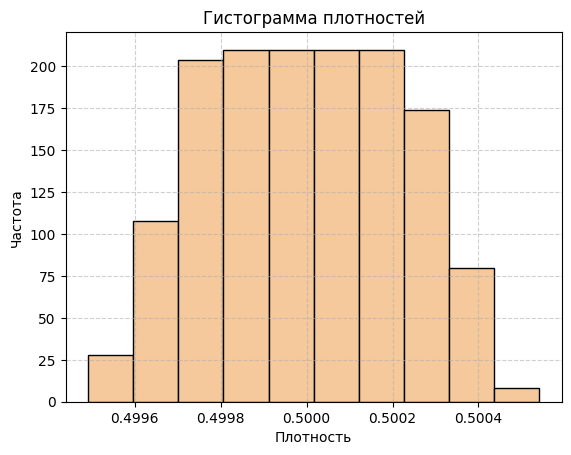

In [32]:
densities = averages_by_density_distance['Density'].to_numpy()
plt.hist(densities, bins=10, edgecolor='black', color='#F5C99B')  # можно изменить bins по желанию
plt.title('Гистограмма плотностей')
plt.xlabel('Плотность')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
mean = np.mean(densities)
std_sample = np.std(densities, ddof=1)

print(f"Математическое ожидание (среднее): {mean}")
print(f"Выборочное стандартное отклонение: {std_sample}")

Математическое ожидание (среднее): 0.4999974826629682
Выборочное стандартное отклонение: 0.0002193099835558846


# Анализ результатов Монте Карло

In [21]:
# Чтение файла логов в датафрейм
df = pd.read_csv('logH2.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])

# Вычисление средних значений по плотности
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean', 'Distance': 'mean', 'p': 'first'}).reset_index()
averages_by_density.rename(columns={'BFS_Result': 'BFS Avg', 'DFS_Result': 'DFS Avg', 'Distance': 'Distance Avg'}, inplace=True)

# Вычисление средних значений по (плотность, расстояние) с количеством пар
averages_by_density_distance = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
averages_by_density_distance.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
averages_by_density_distance['BFS/DFS'] = averages_by_density_distance['BFS Avg'] / averages_by_density_distance['DFS Avg']
averages_by_density_distance = averages_by_density_distance.dropna(subset=['BFS/DFS'])
averages_by_density = averages_by_density[['Density', 'p', 'BFS Avg', 'DFS Avg', 'Distance Avg']]
averages_by_density_distance = averages_by_density_distance[['Density', 'p', 'Distance', 'BFS Avg', 'DFS Avg', 'Count', 'BFS/DFS']]

print("Средние значения по плотности:")
print(averages_by_density)
final_df = averages_by_density_distance.copy()
final_df = final_df.sort_values(by=['p', 'Density'])
#final_df.set_index('Density', inplace=True)
final_df

Средние значения по плотности:
      Density     p   BFS Avg   DFS Avg  Distance Avg
0    0.499492  5000  2436.068  2533.634         1.490
1    0.499500  5000  2553.466  2470.030         1.502
2    0.499515  5000  2487.806  2555.968         1.492
3    0.499522  5000  2593.750  2401.952         1.534
4    0.499531  5000  2477.308  2508.968         1.480
..        ...   ...       ...       ...           ...
716  0.500432  5000  2474.520  2512.300         1.494
717  0.500441  5000  2501.334  2506.252         1.508
718  0.500442  5000  2509.452  2459.850         1.518
719  0.500458  5000  2603.954  2452.522         1.522
720  0.500541  5000  2457.132  2548.038         1.458

[721 rows x 5 columns]


,Density,p,Distance,BFS Avg,DFS Avg,Count,BFS/DFS
0,0.499492,5000,1,1210.098039,3791.901961,255,0.319127
1,0.499492,5000,2,3712.077551,1224.008163,245,3.032723
2,0.499500,5000,1,1260.084337,3741.915663,249,0.336748
3,0.499500,5000,2,3836.541833,1208.278884,251,3.175212
4,0.499515,5000,1,1239.275591,3762.724409,254,0.329356
...,...,...,...,...,...,...,...
1437,0.500442,5000,2,3684.602317,1254.274131,259,2.937637
1438,0.500458,5000,1,1280.430962,3721.569038,239,0.344057
1439,0.500458,5000,2,3815.915709,1290.444444,261,2.957055
1440,0.500541,5000,1,1357.900369,3644.099631,271,0.372630


Проанализируем распределение расстояний

 ### Построим график BFS и DFS от плотности

In [22]:
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
averages_by_density

,Density,BFS_Result,DFS_Result
0,0.499492,2436.068,2533.634
1,0.499500,2553.466,2470.030
2,0.499515,2487.806,2555.968
3,0.499522,2593.750,2401.952
4,0.499531,2477.308,2508.968
...,...,...,...
716,0.500432,2474.520,2512.300
717,0.500441,2501.334,2506.252
718,0.500442,2509.452,2459.850
719,0.500458,2603.954,2452.522


   Distance   BFS_Result   DFS_Result
0         1  1251.141109  3749.828424
1         2  3750.734438  1252.013317


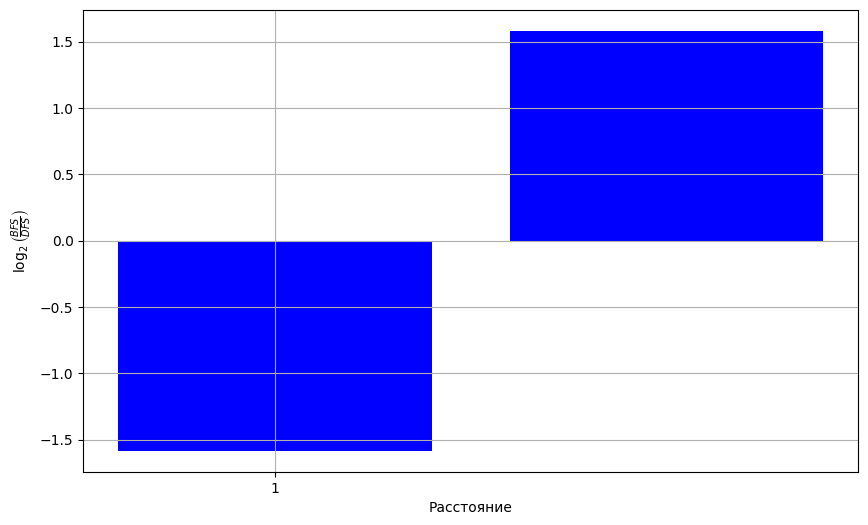

In [23]:
averages_by_dist = df.groupby(['Distance']).agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
print(averages_by_dist)
averages_by_dist['BFS/DFS_Ratio_Log'] = np.log2(averages_by_dist['BFS_Result'] / averages_by_dist['DFS_Result'])

plt.figure(figsize=(10, 6))
plt.bar(averages_by_dist['Distance'], averages_by_dist['BFS/DFS_Ratio_Log'], color = 'blue')
plt.xlabel('Расстояние')
plt.ylabel('$\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$')
plt.title('')
plt.grid()
step = 50 # Шаг между метками
plt.xticks(averages_by_dist['Distance'][::step])  # Убираем метки для промежуточных значений
plt.show()

In [24]:
averages_by_dist_density = df.groupby(['Distance', 'Density']).agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
averages_by_dist_density['BFS/DFS_Ratio_Log'] = np.log2(averages_by_dist_density['BFS_Result'] / averages_by_dist_density['DFS_Result'])

averages_by_dist_density_grouped = averages_by_dist_density.groupby(['Distance']).agg({'BFS/DFS_Ratio_Log':'mean'}).reset_index()
averages_by_dist_density_grouped

,Distance,BFS/DFS_Ratio_Log
0,1,-1.584946
1,2,1.581978


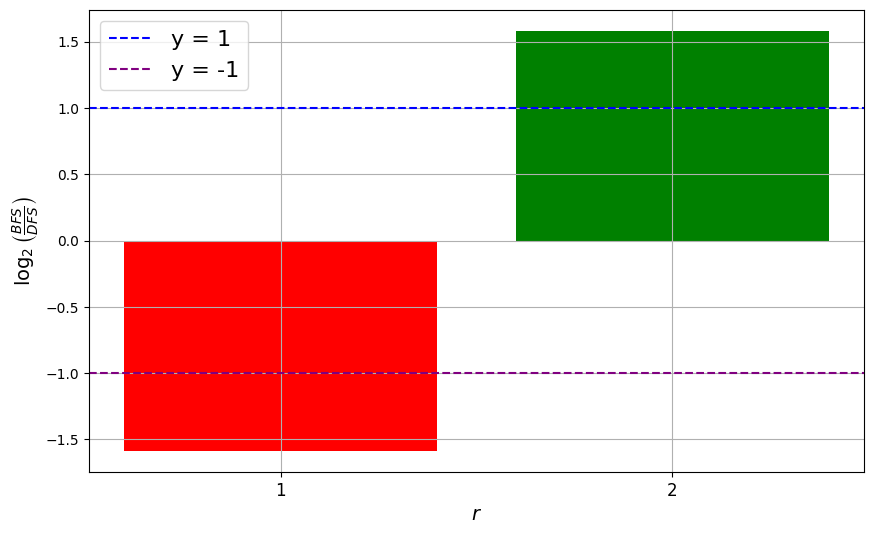

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
positive_mask = averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'] > 0
plt.bar(averages_by_dist_density_grouped['Distance'], averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'], color='r')
plt.bar(averages_by_dist_density_grouped['Distance'][positive_mask], averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'][positive_mask], color='g')
plt.xlabel('$r$', fontsize=14)  # Увеличенный размер шрифта
plt.ylabel('$\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$', fontsize=14)  # Увеличенный размер шрифта
#plt.title('График отношения $\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$ к расстоянию', fontsize=16)  # Увеличенный размер шрифта
step = 1  # Шаг между метками
ticks = [2**i for i in range(int(np.log2(averages_by_dist_density_grouped['Distance'].max())) + 1)]
plt.xticks(ticks, fontsize=12)  # Увеличенный размер шрифта для меток по оси X
plt.grid()

plt.axhline(y=1, color='b', linestyle='--', label='y = 1')
plt.axhline(y=-1, color='purple', linestyle='--', label='y = -1')

plt.legend(fontsize=16)  # Увеличенный размер шрифта для легенды
plt.show()


In [36]:
log_ratios_by_density = averages_by_dist_density.pivot(index='Distance', columns='Density', values='BFS/DFS_Ratio_Log')
log_ratios_by_density.reset_index(inplace=True)

log_ratios_by_density

Density,Distance,0.499492,0.4995,0.499515,0.499522,0.499531,0.499537,0.49954,0.499564,0.499576,...,0.500413,0.500416,0.500423,0.500425,0.500427,0.500432,0.500441,0.500442,0.500458,0.500541
0,1,-1.647798,-1.570257,-1.602281,-1.517842,-1.541397,-1.661519,-1.575849,-1.795714,-1.566803,...,-1.582136,-1.657312,-1.438797,-1.645915,-1.560803,-1.609187,-1.581251,-1.591074,-1.539282,-1.424185
1,2,1.600614,1.666853,1.527686,1.561584,1.661078,1.616502,1.524851,1.475298,1.533052,...,1.688917,1.639148,1.503734,1.610840,1.653473,1.609651,1.510234,1.554656,1.564161,1.586927


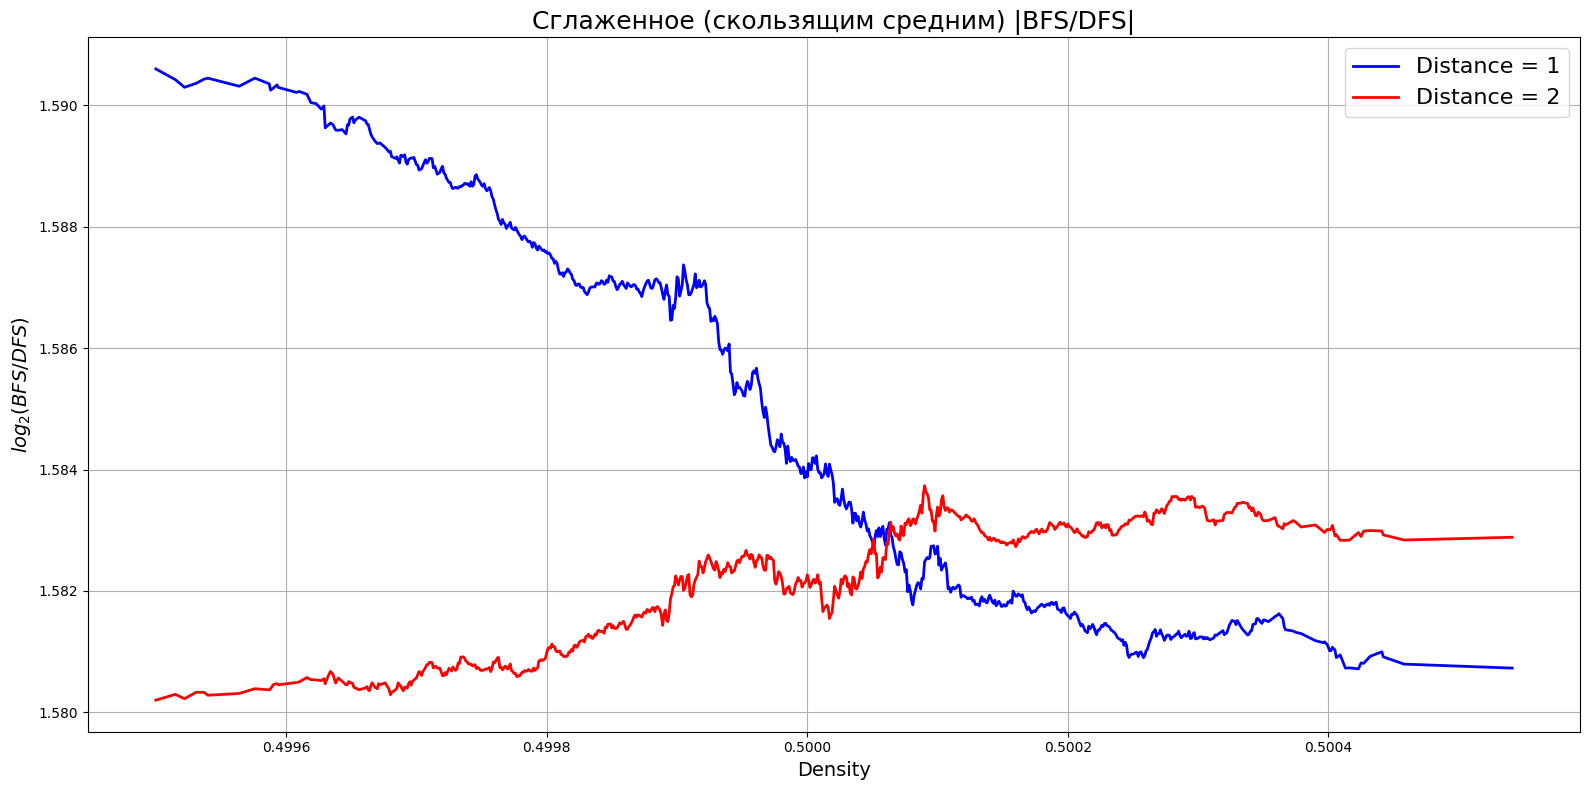

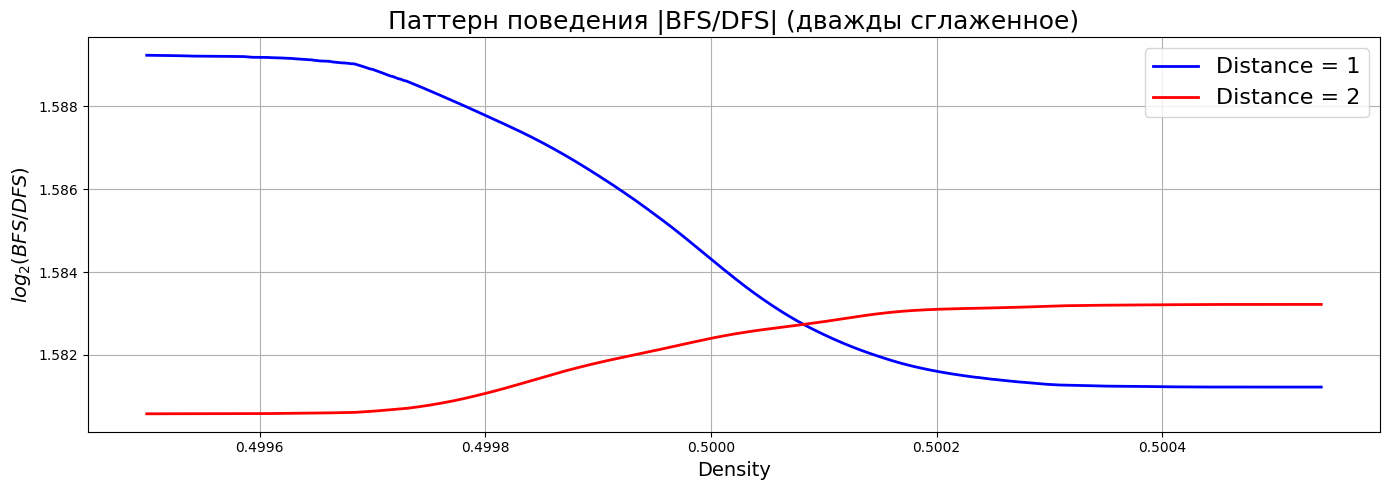

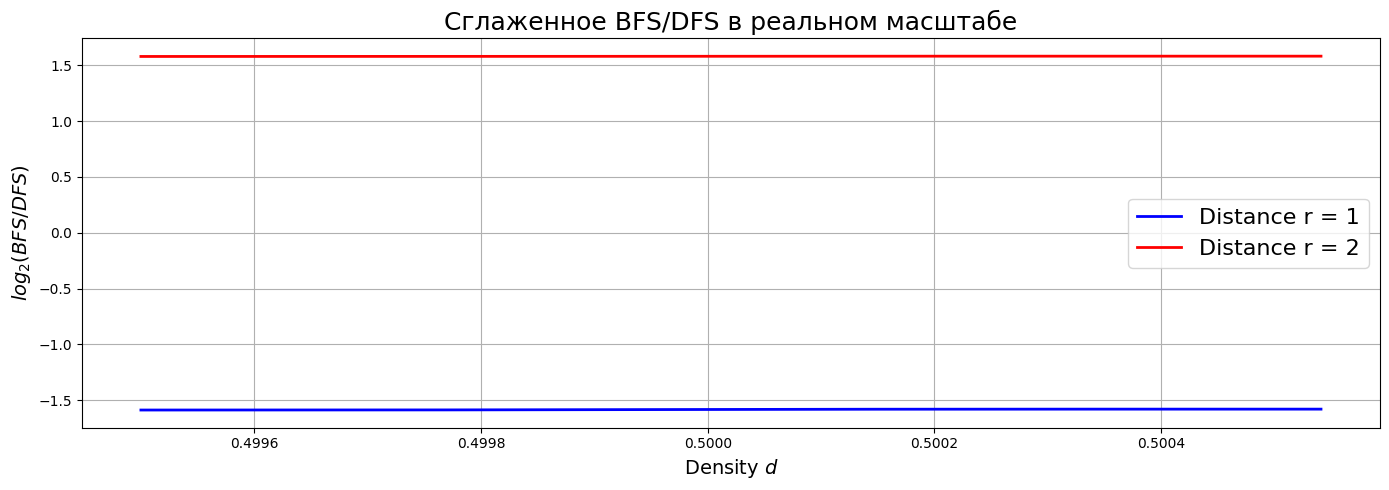

In [85]:
def smooth_series(series, k_list):
    result = pd.Series(series)
    for k in k_list:
        result = result.rolling(window=k, center=True, min_periods=1).mean()
    return result


k = [500]
plt.figure(figsize=(16, 8), dpi=100)
# Значения X
x_values = log_ratios_by_density.columns[2:].astype(float)
x_numeric = np.array(x_values)

# Значения Y
y0 = log_ratios_by_density.iloc[0, 2:].astype(float)
y1 = log_ratios_by_density.iloc[1, 2:].astype(float)

# Сглаженные значения
y0_smooth = smooth_series(y0, k)
y1_smooth = smooth_series(y1, k)

plt.plot(x_numeric, -y0_smooth, label='Distance = 1', linewidth=2, color='blue')
plt.plot(x_numeric, y1_smooth, label='Distance = 2', linewidth=2, color='red')

plt.xlabel('Density', fontsize=14)
plt.ylabel('$log_2(BFS/DFS)$', fontsize=14)
plt.title('Сглаженное (скользящим средним) |BFS/DFS|', fontsize=18)  # увеличенный размер
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

# Построение графика 2
k = [500, 200, 100]
plt.figure(figsize=(14, 5), dpi=100)
# Значения X
x_values = log_ratios_by_density.columns[2:].astype(float)
x_numeric = np.array(x_values)
# Значения Y
y0 = log_ratios_by_density.iloc[0, 2:].astype(float)
y1 = log_ratios_by_density.iloc[1, 2:].astype(float)
# Сглаженные значения
y0_smooth = smooth_series(y0, k)
y1_smooth = smooth_series(y1, k)
plt.plot(x_numeric, -y0_smooth, label='Distance = 1', linewidth=2, color='blue')
plt.plot(x_numeric, y1_smooth, label='Distance = 2', linewidth=2, color='red')
plt.xlabel('Density', fontsize=14)
plt.ylabel('$log_2(BFS/DFS)$', fontsize=14)
plt.title('Паттерн поведения |BFS/DFS| (дважды сглаженное)', fontsize=18)  # увеличенный размер
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


# Построение графика 3
plt.figure(figsize=(14, 5), dpi=100)
plt.plot(x_numeric, y0_smooth, label='Distance r = 1', linewidth=2, color='blue')
plt.plot(x_numeric, y1_smooth, label='Distance r = 2', linewidth=2, color='red')

plt.xlabel('Density $d$', fontsize=14)
plt.ylabel('$log_2(BFS/DFS)$', fontsize=14)
plt.title('Сглаженное BFS/DFS в реальном масштабе', fontsize=18)  # увеличенный размер
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

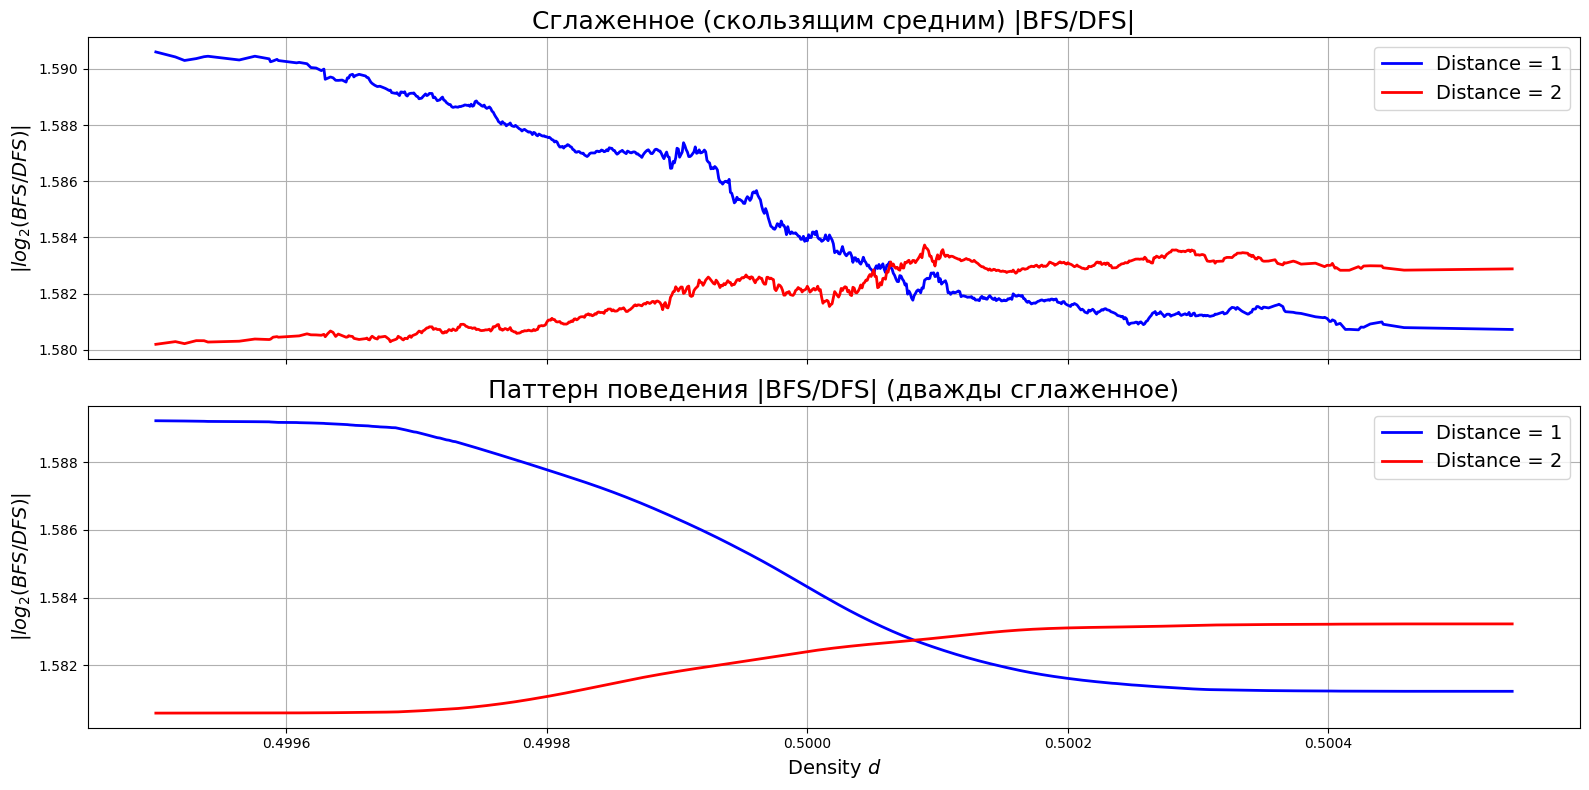

In [82]:
def smooth_series(series, k_list):
    result = pd.Series(series)
    for k in k_list:
        result = result.rolling(window=k, center=True, min_periods=1).mean()
    return result

# Общие данные
x_values = log_ratios_by_density.columns[2:].astype(float)
x_numeric = np.array(x_values)
y0 = log_ratios_by_density.iloc[0, 2:].astype(float)
y1 = log_ratios_by_density.iloc[1, 2:].astype(float)

# Настройка фигуры с 3 графиками
fig, axs = plt.subplots(2, 1, figsize=(16, 8), dpi=100, sharex=True)

# График 1: одно сглаживание
k1 = [500]
y0_smooth_1 = smooth_series(y0, k1)
y1_smooth_1 = smooth_series(y1, k1)

axs[0].plot(x_numeric, -y0_smooth_1, label='Distance = 1', linewidth=2, color='blue')
axs[0].plot(x_numeric, y1_smooth_1, label='Distance = 2', linewidth=2, color='red')
axs[0].set_ylabel('$|log_2(BFS/DFS)|$', fontsize=14)
axs[0].set_title('Сглаженное (скользящим средним) |BFS/DFS|', fontsize=18)
axs[0].legend(fontsize=14)
axs[0].grid(True)

# График 2: многократное сглаживание
k2 = [500, 200, 100]
y0_smooth_2 = smooth_series(y0, k2)
y1_smooth_2 = smooth_series(y1, k2)

axs[1].plot(x_numeric, -y0_smooth_2, label='Distance = 1', linewidth=2, color='blue')
axs[1].plot(x_numeric, y1_smooth_2, label='Distance = 2', linewidth=2, color='red')
axs[1].set_ylabel('$|log_2(BFS/DFS)|$', fontsize=14)
axs[1].set_xlabel('Density $d$', fontsize=14)

axs[1].set_title('Паттерн поведения |BFS/DFS| (дважды сглаженное)', fontsize=18)
axs[1].legend(fontsize=14)
axs[1].grid(True)

# # График 3: реальные значения после многократного сглаживания
# axs[2].plot(x_numeric, y0_smooth_2, label='Distance r = 1', linewidth=2, color='blue')
# axs[2].plot(x_numeric, y1_smooth_2, label='Distance r = 2', linewidth=2, color='red')
# axs[2].set_xlabel('Density', fontsize=14)
# axs[2].set_ylabel('BFS/DFS Ratio (Log)', fontsize=14)
# axs[2].set_title('Сглаженное BFS/DFS в реальном масштабе', fontsize=18)
# axs[2].legend(fontsize=14)
# axs[2].grid(True)

plt.tight_layout()
plt.show()

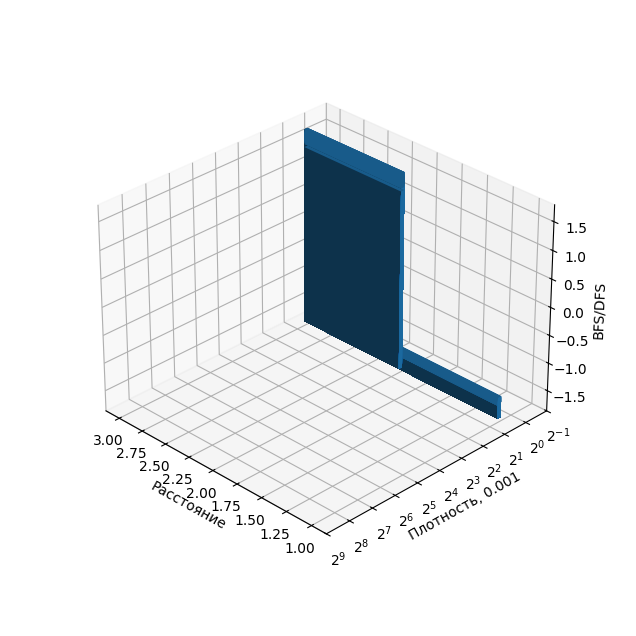

In [ ]:
df = pd.read_csv('logH2.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])
df = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
df.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
df['BFS/DFS'] = np.log2(df['BFS Avg'] / df['DFS Avg'])

#df['Density'] = np.log2(df['Density']/0.001)
y_ticks = np.linspace(-1, 9, endpoint=True, num=11)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')
ax.azim = 135
ax.bar3d(df['Distance'], df['Density'], min(df['BFS/DFS']), 1, 0.15, df['BFS/DFS']-min(df['BFS/DFS']))
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(-1, 10)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(-1, 10)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

ValueError: zero-size array to reduction operation minimum which has no identity

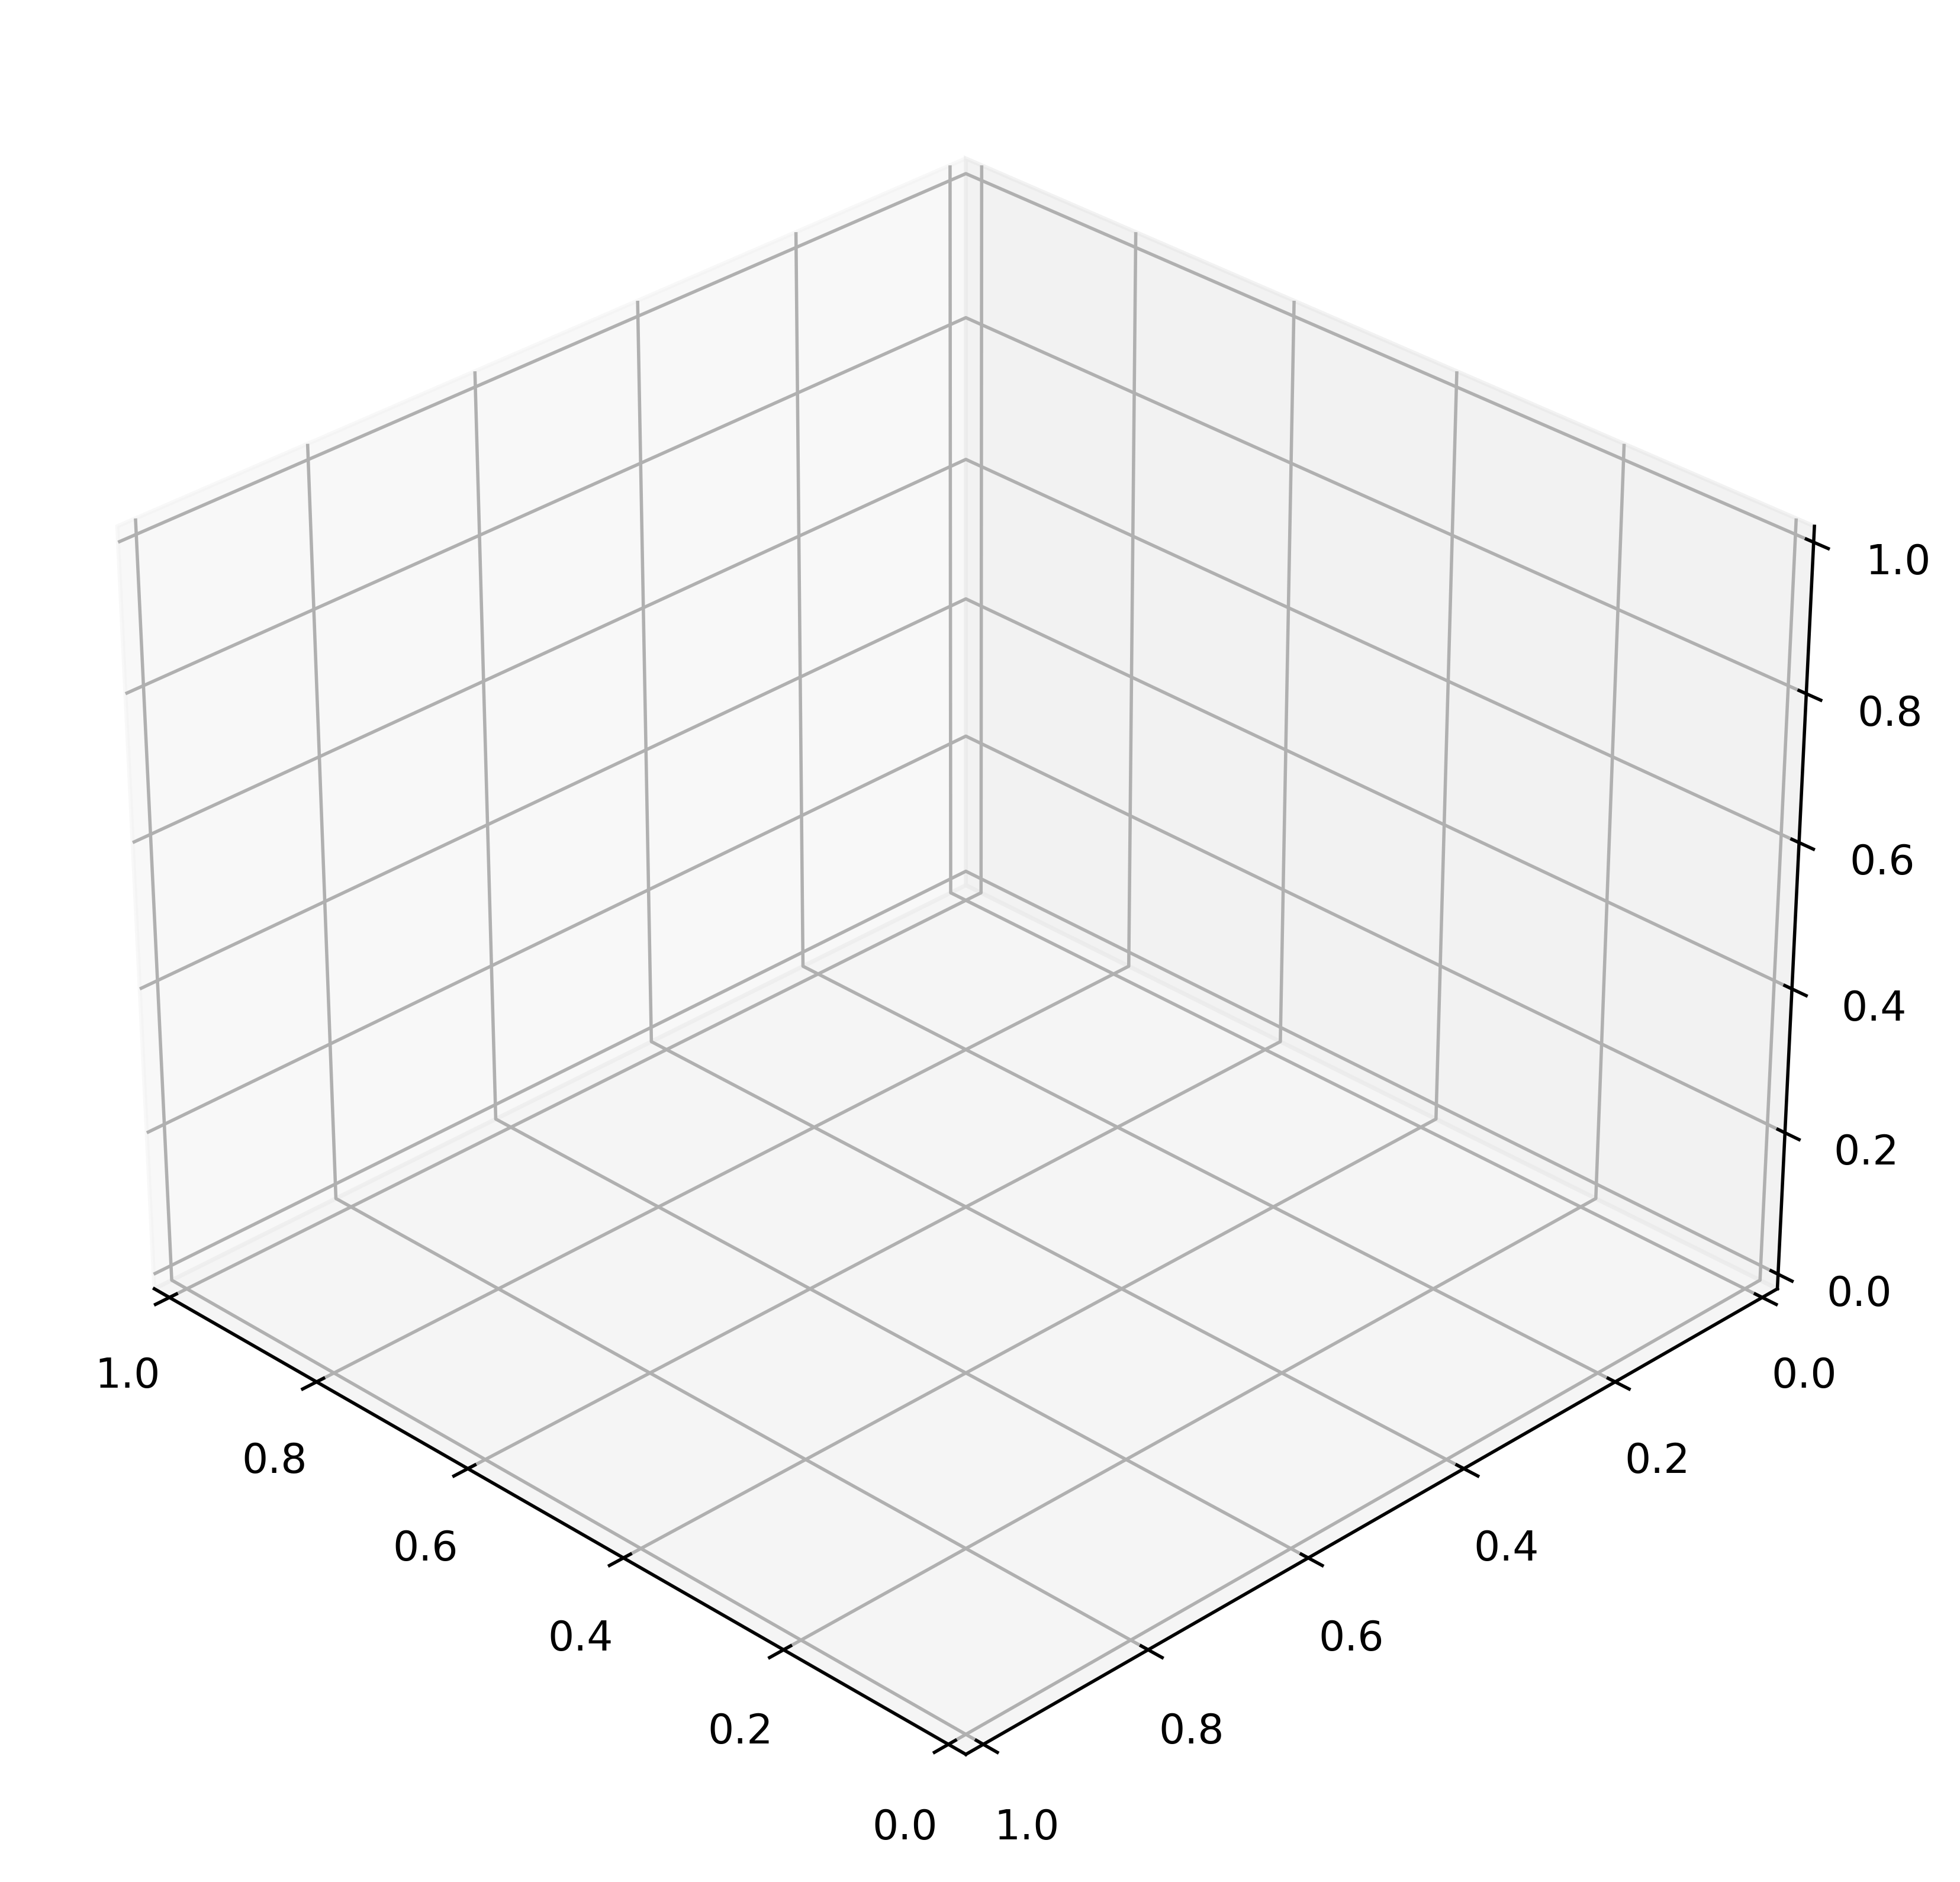

In [ ]:
df_low_den = df[df['Density'] <= 1]
fig = plt.figure(figsize=(12, 8), dpi=500)
ax = fig.add_subplot(projection='3d')
ax.azim = 135
bdp = df_low_den[df_low_den['BFS/DFS'] > 0]
bdm = df_low_den[df_low_den['BFS/DFS'] <= 0]
ax.bar3d(bdm['Distance'], bdm['Density'], 0, 0.7, 0.1, bdm['BFS/DFS'], color='r')
ax.bar3d(bdp['Distance'], bdp['Density'], 0, 0.7, 0.1, bdp['BFS/DFS'], color='g')
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_xlim(0, 27)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-10, 3)

xx, yy = np.meshgrid(range(28), range(28))
zz = xx*yy*0
ax.plot_surface(xx, yy/28*2.2 - 1.1, zz, alpha=0.2)
y_ticks = np.linspace(-1, 1, endpoint=True, num=3)
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(-1, 2)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(-1, 2)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

C:\Users\skiva\AppData\Local\Temp\ipykernel_3708\1936405134.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


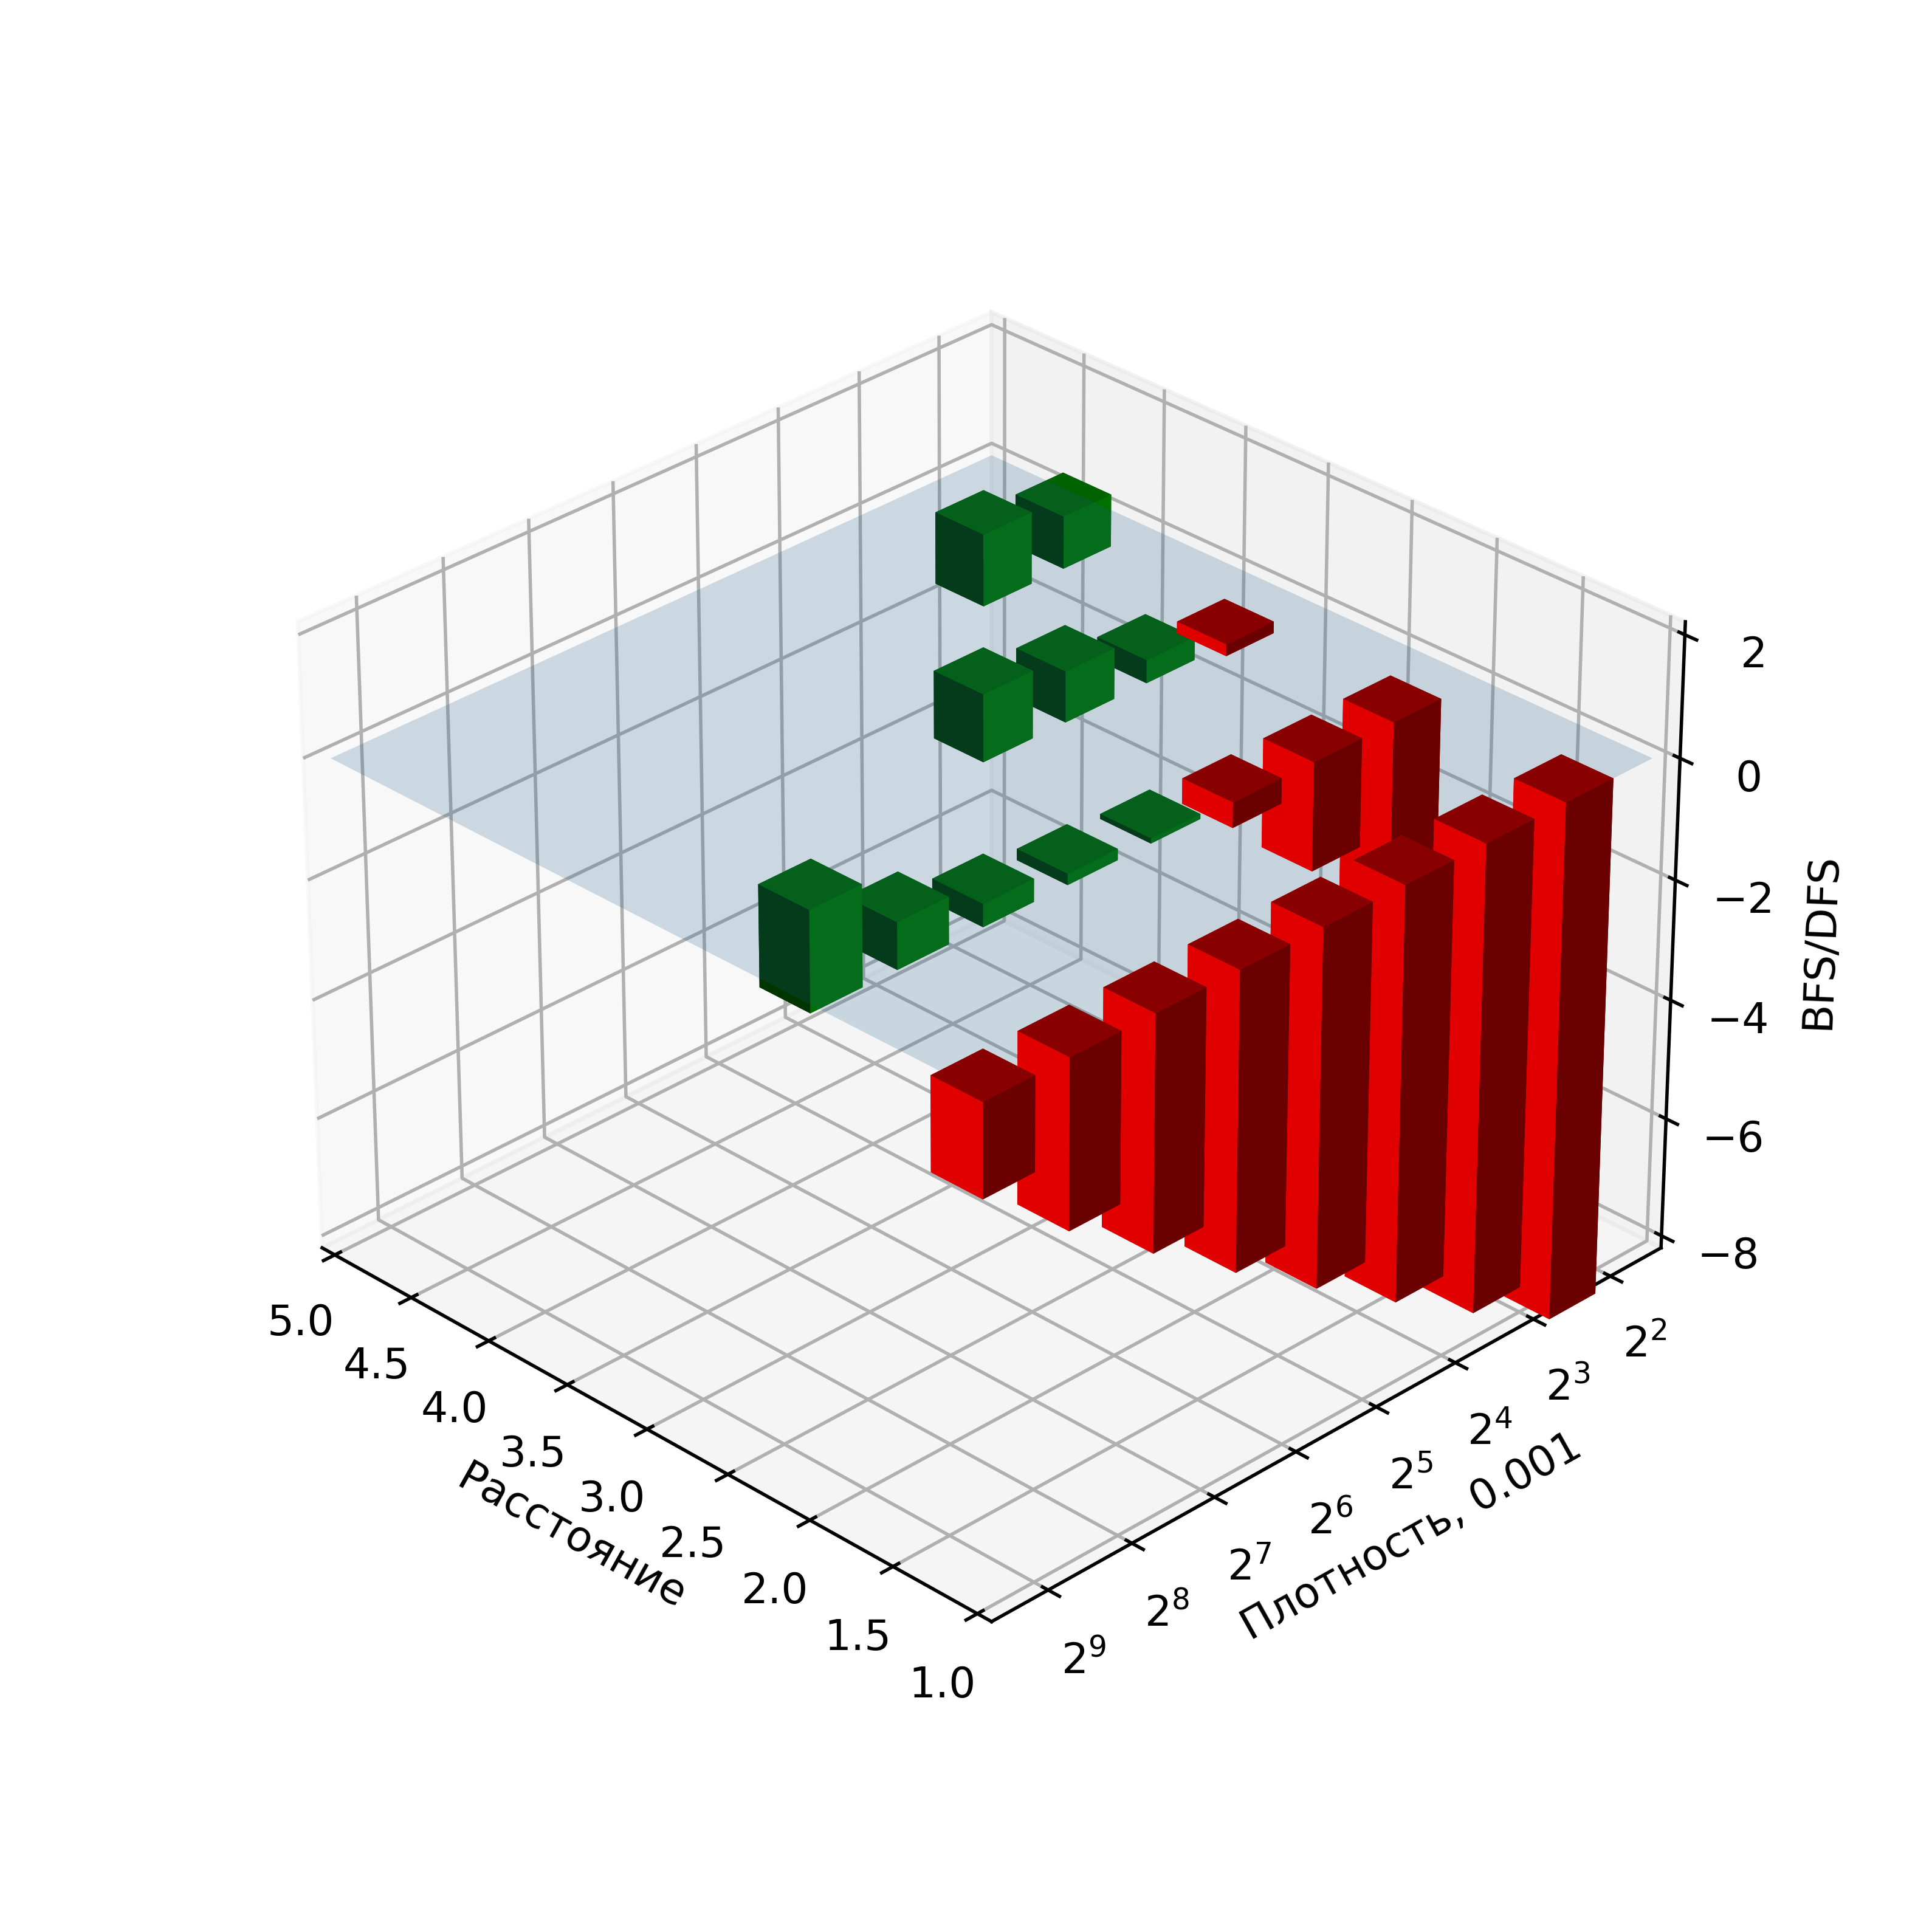

In [ ]:
df_high_den = df[df['Density'] > 1]
fig = plt.figure(figsize=(12, 8), dpi=500)
ax = fig.add_subplot(projection='3d')
ax.view_init(azim=135)
bdp = df_high_den[df_high_den['BFS/DFS'] > 0]
bdm = df_high_den[df_high_den['BFS/DFS'] <= 0]
#ax.bar3d(df_high_den['Distance'], df_high_den['Density'], min(df_high_den['BFS/DFS']), 1, 1, df_high_den['BFS/DFS']-min(df_high_den['BFS/DFS']))
ax.bar3d(bdm['Distance'], bdm['Density'], 0, 0.3, 0.6, bdm['BFS/DFS'], color='r')
ax.bar3d(bdp['Distance'], bdp['Density'], 0, 0.3, 0.6, bdp['BFS/DFS'], color='g')
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_xlim(1, 5)
ax.set_ylim(1.5, 9.5)
ax.set_zlim(-8, 2)
xx, yy = np.meshgrid(range(1, 6), range(5))
zz = xx*yy*0
ax.plot_surface(xx, yy*2 + 1.5, zz, alpha=0.2)
y_ticks = np.linspace(2, 9, endpoint=True, num=8)
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(2, 10)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(2, 10)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

In [ ]:
count_table = df_high_den.groupby(['Density', 'Distance'])['Count'].sum().unstack(fill_value=0)
count_table

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

mask = count_table == 0
fig, ax = plt.subplots(figsize=(40, 15), dpi=300)  # Установлен большой размер и высокий DPI

# Транспонируем как данные, так и маску
sns.heatmap(count_table.T, cmap='Blues', annot=True, fmt='d', ax=ax, cbar_kws={'label': 'Количество значений'},
            linewidths=0, linecolor='white', square=True, annot_kws={"size": 24}, mask=mask.T)

# Инвертируем оси
ax.invert_yaxis()  # Инвертируем ось Y, чтобы значения шли снизу вверх
# ax.invert_xaxis()  # Инвертируем ось X, чтобы значения шли слева направо

ax.set_xlabel('Логарифм плотности $\log_2{(d/0.001)}$', fontsize=40, labelpad=25)
ax.set_ylabel('Расстояние $r$', fontsize=40, labelpad=25)
ax.set_title('Тепловая карта расстояние/плотность', fontsize=40, pad=30)

ax.tick_params(axis='both', which='major', labelsize=28)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=28)
cbar.set_label('Количество значений', fontsize=40, labelpad=25)

plt.tight_layout(pad=5)
plt.show()

NameError: name 'df_high_den' is not defined

# Модель Гильберта